# Augmentation Training

This notebook trains the same baseline CNN architecture using data augmentation to evaluate whether exposure to transformed training images improves clean generalization and robustness to image corruptions.

In [6]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

In [5]:
# CIFAR-10 normalization statistics
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

# Training transform with data augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(
        size=32,
        padding=4
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation and test transform
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load CIFAR-10 datasets
train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=train_transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=eval_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=eval_transform
)

# Reproduce the same train/validation split used for the baseline model
all_indices = np.arange(len(train_dataset))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=42,
    stratify=train_dataset.targets
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_dataset))

Training samples: 45000
Validation samples: 5000
Test samples: 10000


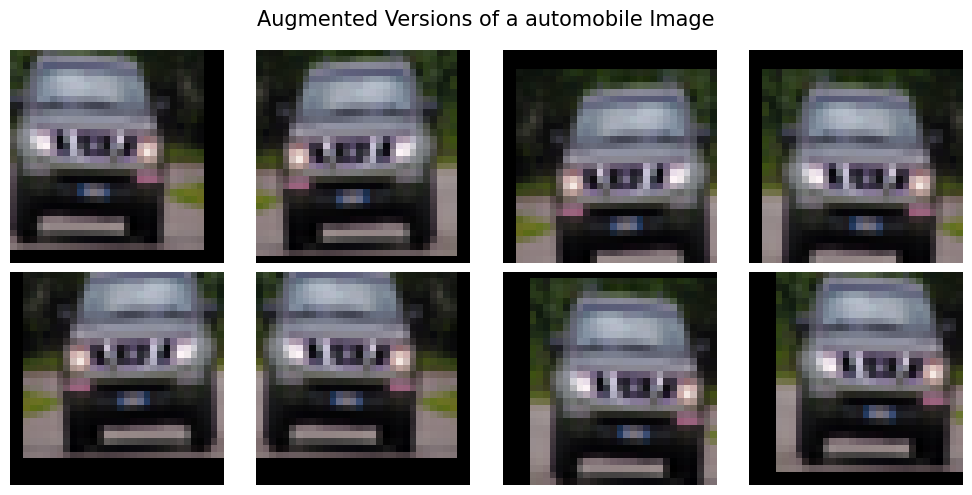

In [15]:
# Visualize multiple augmented versions of the same training image
sample_index = train_indices[0]
label = train_dataset.targets[sample_index]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for ax in axes.flat:
    image, _ = train_dataset[sample_index]

    # Denormalize for visualization
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    image = image * std_tensor + mean_tensor
    image = torch.clamp(image, 0.0, 1.0)

    ax.imshow(image.permute(1, 2, 0))
    ax.axis("off")

fig.suptitle(
    f"Augmented Versions of a {train_dataset.classes[label]} Image",
    fontsize=15
)

plt.tight_layout()
plt.show()